In [1]:
from typing_extensions import TypedDict
from langfuse.langchain import CallbackHandler
from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

langfuse_trace = CallbackHandler()


In [4]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="llama-3.1-8b-instant")

In [5]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4.1-nano")
llm.invoke("Hello", config={"callbacks": [langfuse_trace]})

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_e3fcbabb13', 'id': 'chatcmpl-DueWmTtl3jluPAg2JXJN28YBPWbfD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019efefe-1d11-7942-9291-b34d9a1b48d7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [6]:
### Create Nodes
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def superbot(state: State):
    return {"messages": [llm_groq.invoke(state["messages"])]}

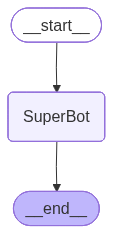

In [7]:
graph = StateGraph(State)

### node
graph.add_node("SuperBot", superbot)
### edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [8]:
config = {'configurable': {"thread_id": "1"}, "callbacks": [langfuse_trace]}

graph_builder.invoke(
    {'messages':"Hi,My name is Tho And I like cricket"},
    config
)

{'messages': [HumanMessage(content='Hi,My name is Tho And I like cricket', additional_kwargs={}, response_metadata={}, id='f0536974-2128-4101-b00e-c6dac54cb0bf'),
  AIMessage(content='Hi Tho, nice to meet you. Cricket is a fantastic sport with a rich history and a huge global following. Which team or player do you support? Are you more into Test cricket, One-Day Internationals (ODIs), or the shorter format of Twenty20 (T20) cricket?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 46, 'total_tokens': 108, 'completion_time': 0.102590649, 'completion_tokens_details': None, 'prompt_time': 0.002142779, 'prompt_tokens_details': None, 'queue_time': 0.052673861, 'total_time': 0.104733428}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efefe-23d2-7ec0-a5a5-06079a609d02-0', tool_calls=[], invalid_tool

In [9]:
### Streaming
config = {'configurable': {"thread_id": "2"}, "callbacks": [langfuse_trace]}

for chunk in graph_builder.stream(
    {
        'messages':"Hi,My name is Tho And I like cricket"
    },
    config=config,
    stream_mode="updates",
):
    print(chunk)


{'SuperBot': {'messages': [AIMessage(content='Nice to meet you, Tho. Cricket is a fantastic sport with a huge following worldwide, especially in countries like India, Australia, and the UK. Which team or player is your favorite in cricket? Are you a fan of international cricket or domestic leagues like the Indian Premier League (IPL)?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 46, 'total_tokens': 107, 'completion_time': 0.081532005, 'completion_tokens_details': None, 'prompt_time': 0.002154239, 'prompt_tokens_details': None, 'queue_time': 0.049832307, 'total_time': 0.083686244}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efefe-2571-7d51-91a3-978472f69041-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 61, 'total_tokens': 107})]}}


In [10]:
for chunk in graph_builder.stream(
    {
        'messages':"I also like football"
    },
    config=config,
    stream_mode="values",
):
    print(chunk)


{'messages': [HumanMessage(content='Hi,My name is Tho And I like cricket', additional_kwargs={}, response_metadata={}, id='9749f03c-2bcf-4fac-ac35-5d654a802015'), AIMessage(content='Nice to meet you, Tho. Cricket is a fantastic sport with a huge following worldwide, especially in countries like India, Australia, and the UK. Which team or player is your favorite in cricket? Are you a fan of international cricket or domestic leagues like the Indian Premier League (IPL)?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 46, 'total_tokens': 107, 'completion_time': 0.081532005, 'completion_tokens_details': None, 'prompt_time': 0.002154239, 'prompt_tokens_details': None, 'queue_time': 0.049832307, 'total_time': 0.083686244}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efefe-2571-7d51-91a3-978472f6

In [11]:
for chunk in graph_builder.stream(
    {
        'messages':"I also like football"
    },
    config=config,
    stream_mode="updates",
):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='It looks like you like football (soccer) quite a bit. Do you have a favorite team or player in football, or do you prefer to watch and follow different leagues and tournaments?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 210, 'total_tokens': 249, 'completion_time': 0.07563161, 'completion_tokens_details': None, 'prompt_time': 0.011826147, 'prompt_tokens_details': None, 'queue_time': 0.158048232, 'total_time': 0.087457757}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efefe-2834-75a2-a9ec-64825bfa8883-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 210, 'output_tokens': 39, 'total_tokens': 249})]}}


In [12]:
for chunk in graph_builder.stream(
    {
        'messages':"I Love sports"
    },
    config=config,
    stream_mode="values",
):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Tho And I like cricket', additional_kwargs={}, response_metadata={}, id='9749f03c-2bcf-4fac-ac35-5d654a802015'), AIMessage(content='Nice to meet you, Tho. Cricket is a fantastic sport with a huge following worldwide, especially in countries like India, Australia, and the UK. Which team or player is your favorite in cricket? Are you a fan of international cricket or domestic leagues like the Indian Premier League (IPL)?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 46, 'total_tokens': 107, 'completion_time': 0.081532005, 'completion_tokens_details': None, 'prompt_time': 0.002154239, 'prompt_tokens_details': None, 'queue_time': 0.049832307, 'total_time': 0.083686244}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efefe-2571-7d51-91a3-978472f6

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [ ]:
config = {"configurable": {"thread_id": "3"}, "callbacks": [langfuse_trace]}

async for event in graph_builder.astream_events(
    {"messages": ["Hi, my name is Tho and I like to play criket"]},
    config,
    version="v2",
):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi, my name is Tho and I like to play criket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019eff04-0dc1-7b42-b8d5-d00dde95af72', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, my name is Tho and I like to play criket', additional_kwargs={}, response_metadata={}, id='cffa8eaa-ee79-4b50-8723-b2a9bd2f0e8c')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019eff04-0dc5-7841-b1df-3db2efb79213', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:3f348e1a-a9b8-20c1-04d3-63114bf77d82'}, 'parent_ids': ['019eff04-0dc1-7b42-b8d5-d00dde95af72']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[H